In [6]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import warnings
from datetime import datetime
import re
from treetime import TreeTime, TreeTimeError, utils
from dendropy import Tree
from Bio import SeqIO
import random
import math
import scipy.stats as stats
from collections import Counter
from scipy.stats import gaussian_kde

In [7]:
clades = ['h3nx', 'na_avian', 'eurasian_avian', 'swine', 'human', 'equine', 'canine']

In [8]:
host_trees = {}

for clade in clades:
    
    path = f'{clade}/summary_baltic.nwk'
    mytree= bt.loadNewick(path, absoluteTime= False)

    
    host_trees[clade] = mytree

for clade in clades:
    
    mytree = host_trees[clade]

    for k in mytree.Objects:
        
        name = k.name if k.is_leaf() else k.traits["label"]


In [9]:
def parse_dates(aln_path: str):
    records = SeqIO.parse(aln_path, 'fasta')
    dates = {}
    for record in records:
        name = record.name
        # date_str = name.split('|')[-1]
        date = None
        for token in name.split('|'):
            if re.fullmatch(r'[\d\-/]{4,}', token) and not re.fullmatch(r'\d{5,}', token):
                if token.count('/') == 2:
                    date = datetime.strptime(token, '%m/%d/%Y')
                elif token.count('/') == 1:
                    date = datetime.strptime(token, '%m/%Y')
                elif token.count('-') == 2:
                    date = datetime.strptime(token, '%Y-%m-%d')
                elif token.count('-') == 1:
                    date = datetime.strptime(token, '%Y-%m')
                else:
                    date = datetime.strptime(token, '%Y')
        if not date:
            pass
        else:
            dec_date = date.year + ((date.month - 1) * 30 + date.day) / 365.0
            dates[name] = dec_date
    return dates

def estimate_clock_rate(tree_path: str, aln_path: str, outdir='.') -> (float, float):
    
    # This code was adapted from the  'estimate_clock_model' method in the treetime/wrappers.py.
    tree: Tree = Tree.get(path=tree_path, schema='newick', preserve_underscores=True)
    if len(tree.leaf_nodes()) > 1000:
        tree_path = os.path.join(outdir, os.path.split(tree_path)[-1] + '.sample1k.tre')
        taxa_labels = [t.label for t in tree.taxon_namespace]
        random.shuffle(taxa_labels)
        subtree: Tree = tree.extract_tree_with_taxa_labels(taxa_labels[:1000])
        subtree.write(path=tree_path, schema='newick')

    dates = parse_dates(aln_path)
    
    timetree = TreeTime(dates=dates, tree=tree_path, aln=aln_path, gtr='JC69', verbose=-1)  # TODO: JC->GTR?
          
    timetree.clock_filter(n_iqd=3, reroot='least-squares')
    timetree.use_covariation = True
    timetree.reroot()
    timetree.get_clock_model(covariation=True)
    
    # trying to get root here, but it changes quite unstably from inference to inference
    # should i resolve polytomies?
    timetree.run(root='least-squares', resolve_polytomies=True)

    inferred_root_date = timetree.tree.root.numdate
    print(f"inferred root date: {inferred_root_date:.4f}")

    r_val = timetree.clock_model['r_val']
    
    d2d = utils.DateConversion.from_regression(timetree.clock_model)
    clock_rate = round(d2d.clock_rate, 7)
    
    return d2d.clock_rate, r_val, inferred_root_date
    

In [10]:
host_stats = {}

for clade in clades:
    
    print(clade)
    
    clock_rate, r_val, root_yr = estimate_clock_rate(f"{clade}/summary.nwk", f"{clade}/h3nx_ha.fasta")
    
    host_stats[clade] = {
    'clock_rate': clock_rate,
    'root_yr': root_yr
    }

h3nx
inferred root date: 1942.6856
na_avian
inferred root date: 1931.2042
eurasian_avian
inferred root date: 1934.3055
swine
inferred root date: 1972.3444
human
inferred root date: 1967.2012
equine
inferred root date: 1954.5948
canine
inferred root date: 2004.4503


# reassorted lineages

In [11]:
clade_persistences = {clade: {} for clade in host_trees.keys()}

for clade in clades:
    
    count = 0
    
    mytree = host_trees[clade] 

    mytree.traverse_tree()  
    mytree.sortBranches()

    leaf_heights = {}

    for leaf in mytree.getExternal():

        leaf_heights[leaf.name] = (leaf.height, leaf.name.split("|")[1])
    
    clade_persistence = []

    for k in mytree.Objects:

        # only want to look at reassorted nodes
        
        if k.is_leaf():

            continue

        elif k.is_node() and k.traits.get('is_reassorted'):
            
            count+=1
            
            # record date of most recent tip 
            # persistence = tip year - node year

            dates_and_heights = [(leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves]
            # print(k.height, [(leaf, leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves])

            max_date, leaf_height = max(dates_and_heights, key=lambda x: x[0]) # date and height for most recent / youngest leaf based on its annotated date

            # branch leading to 2 leaves sometimes will have persistence = 0 if the node and its most recent descendent have the same div value
            persistence = (leaf_height - k.height) / host_stats[clade]['clock_rate']
            
            clade_persistence.append(persistence)
            
    print(clade,count)
            
    clade_persistences[clade] = clade_persistence
            

h3nx 741
na_avian 306
eurasian_avian 88
swine 159
human 4
equine 2
canine 3


In [12]:
na_avian_persistences = np.concatenate([clade_persistences["na_avian"]])
eu_avian_persistences = np.concatenate([clade_persistences["eurasian_avian"]])
swine_persistences = np.concatenate([clade_persistences["swine"]])

In [26]:
def summarize(x):
    return {
        "mean": np.mean(x),
        "sd": np.std(x, ddof=1),   # sample SD
        "median": np.median(x)
    }

na_avian_stats = summarize(na_avian_persistences)
eu_avian_stats = summarize(eu_avian_persistences)
swine_stats = summarize(swine_persistences)

print("NA Avian:")
for k, v in na_avian_stats.items():
    print(f"  {k}: {v:.2f}")
    
print("\nEurasian Avian:")
for k, v in eu_avian_stats.items():
    print(f"  {k}: {v:.2f}")

print("\nSwine:")
for k, v in swine_stats.items():
    print(f"  {k}: {v:.2f}")


NA Avian:
  mean: 4.02
  sd: 8.27
  median: 0.83

Eurasian Avian:
  mean: 8.81
  sd: 17.80
  median: 3.85

Swine:
  mean: 4.96
  sd: 7.11
  median: 2.51


21
30
26


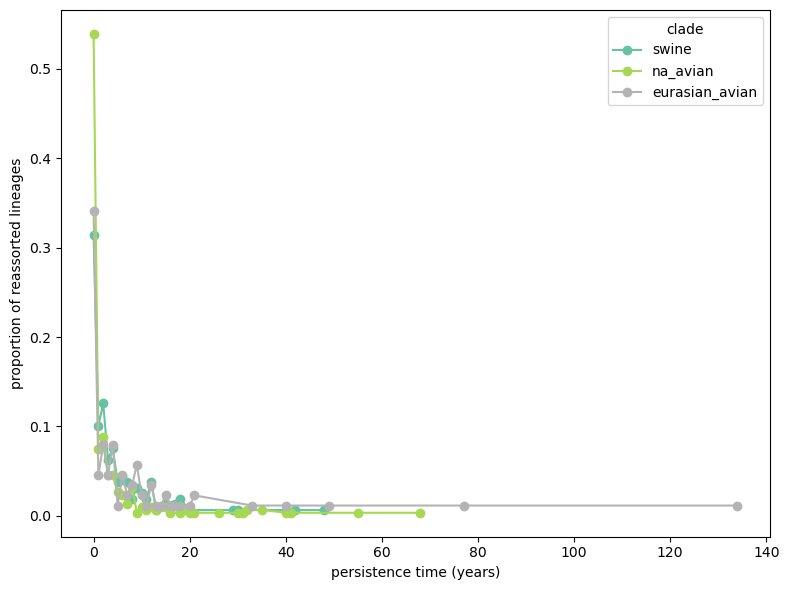

In [15]:
subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8,6))

for (clade, persistences), color in zip(filtered.items(), colors):

    # bin persistence times to years (floor)
    binned = np.floor(persistences)
    counts = Counter(binned)
    
    print(len(counts))

    total = len(persistences)
    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])

    plt.plot(years, proportions, marker="o", label=clade, color=color)

plt.xlabel("persistence time (years)")
plt.ylabel("proportion of reassorted lineages")
plt.legend(title="clade")
plt.tight_layout()
plt.show()


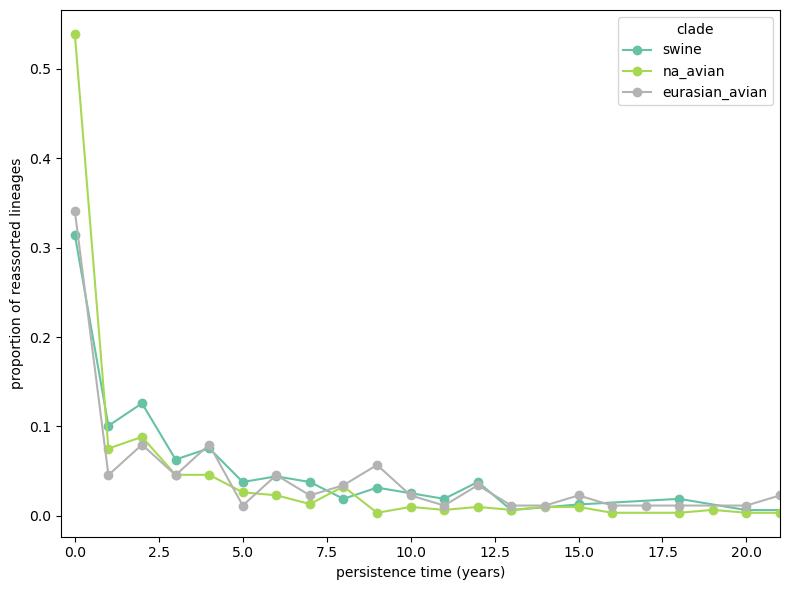

In [16]:
subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8,6))

for (clade, persistences), color in zip(filtered.items(), colors):

    binned = np.floor(persistences)

    counts = Counter(binned)

    total = len(persistences)
    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])


    plt.plot(years, proportions, marker="o", label=clade, color=color)

plt.xlabel("persistence time (years)")
plt.ylabel("proportion of reassorted lineages")
plt.xlim(-0.4, 21)
plt.legend(title="clade")
plt.tight_layout()
plt.show()


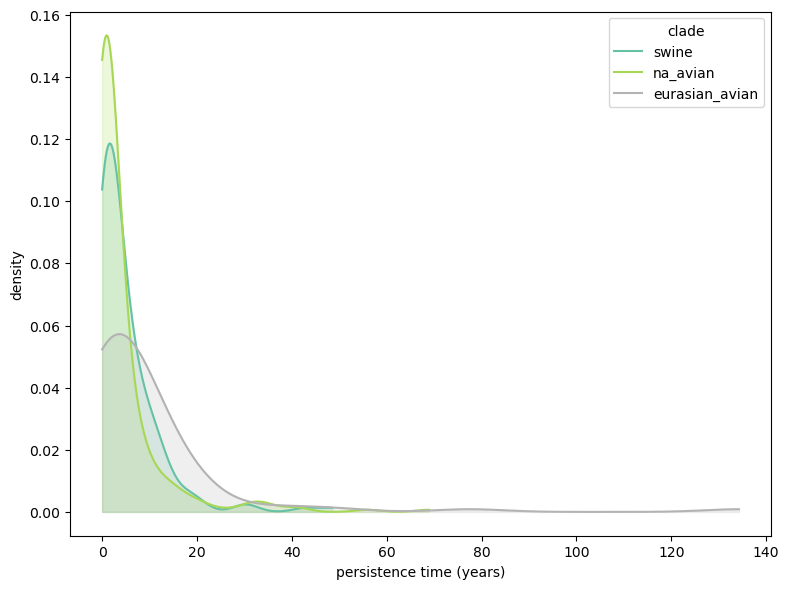

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8,6))

for (clade, persistences), color in zip(filtered.items(), colors):

    x = np.array(persistences)

    kde = gaussian_kde(x)

    xx = np.linspace(min(x), max(x), 500)
    yy = kde(xx)

    # scale so that the area under the curve = 1 → fraction of lineages
    yy = yy / yy.sum() / (xx[1] - xx[0])

    plt.plot(xx, yy, label=clade, color=color)
    plt.fill_between(xx, yy, alpha=0.2, color=color)  # optional: shaded area

plt.xlabel("persistence time (years)")
plt.ylabel("density")
plt.legend(title="clade")
plt.tight_layout()
plt.show()


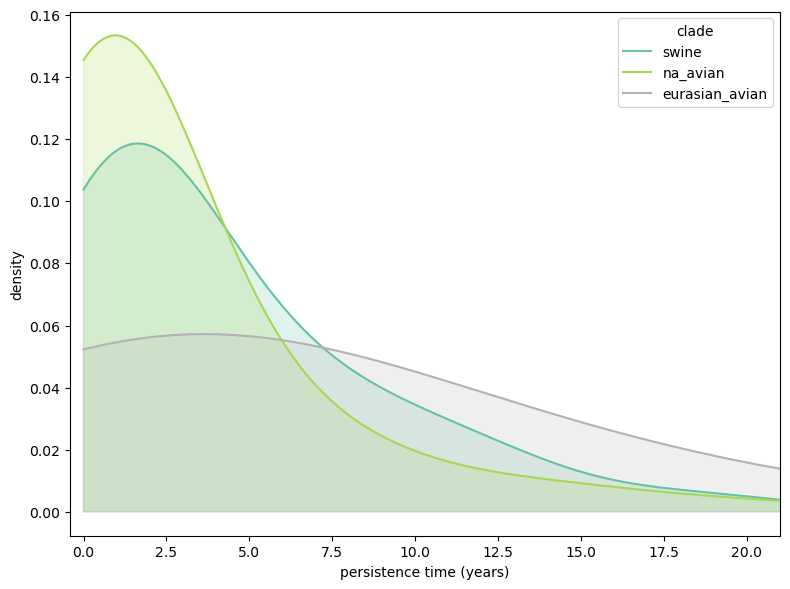

In [18]:
subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8,6))

for (clade, persistences), color in zip(filtered.items(), colors):

    x = np.array(persistences)

    kde = gaussian_kde(x)

    xx = np.linspace(min(x), max(x), 500)
    yy = kde(xx)

    # scale so that the area under the curve = 1 → fraction of lineages
    yy = yy / yy.sum() / (xx[1] - xx[0])

    plt.plot(xx, yy, label=clade, color=color)
    plt.fill_between(xx, yy, alpha=0.2, color=color)  # optional: shaded area

plt.xlabel("persistence time (years)")
plt.ylabel("density")
plt.xlim(-0.4, 21)
plt.legend(title="clade")
plt.tight_layout()
plt.show()


# nonreassorted lineages

In [19]:
clade_nonrea_persistences = {clade: {} for clade in host_trees.keys()}

for clade in clades:
    
    count = 0
    
    mytree = host_trees[clade] 

    mytree.traverse_tree()  
    mytree.sortBranches()

    leaf_heights = {}

    for leaf in mytree.getExternal():

        leaf_heights[leaf.name] = (leaf.height, leaf.name.split("|")[1])
    
    clade_persistence = []

    for k in mytree.Objects:

        # only want to look at reassorted nodes
        
        if k.is_leaf():

            continue

        elif k.is_node() and not k.traits.get('is_reassorted'):
            
            count+=1
            
            # record date of most recent tip 
            # persistence = tip year - node year

            dates_and_heights = [(leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves]
            # print(k.height, [(leaf, leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves])

            max_date, leaf_height = max(dates_and_heights, key=lambda x: x[0]) # date and height for most recent / youngest leaf based on its annotated date

            # branch leading to 2 leaves sometimes will have persistence = 0 if the node and its most recent descendent have the same div value
            persistence = (leaf_height - k.height) / host_stats[clade]['clock_rate']
            
            clade_persistence.append(persistence)
    print(clade,count)
            
    clade_nonrea_persistences[clade] = clade_persistence
            

h3nx 4519
na_avian 887
eurasian_avian 979
swine 1856
human 230
equine 221
canine 421


41
52
74


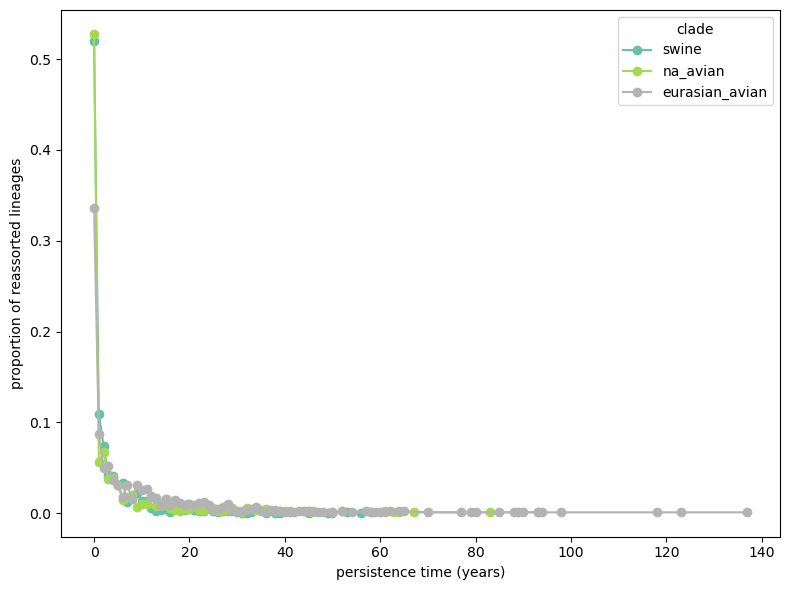

In [20]:
subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_nonrea_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8,6))

for (clade, persistences), color in zip(filtered.items(), colors):

    # bin persistence times to years (floor)
    binned = np.floor(persistences)
    counts = Counter(binned)
    
    print(len(counts))

    total = len(persistences)
    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])

    plt.plot(years, proportions, marker="o", label=clade, color=color)

plt.xlabel("persistence time (years)")
plt.ylabel("proportion of reassorted lineages")
plt.legend(title="clade")
plt.tight_layout()
plt.show()

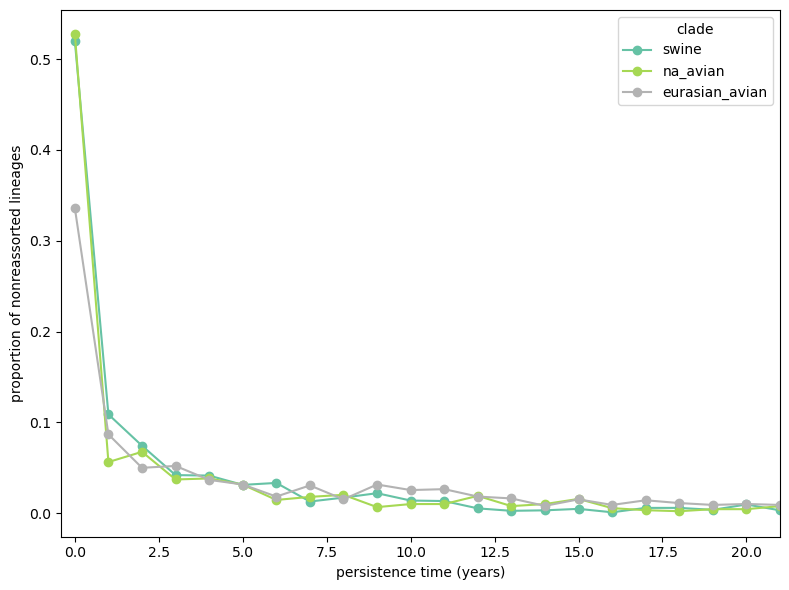

In [21]:
subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_nonrea_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8,6))

for (clade, persistences), color in zip(filtered.items(), colors):

    binned = np.floor(persistences)

    counts = Counter(binned)

    total = len(persistences)
    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])


    plt.plot(years, proportions, marker="o", label=clade, color=color)

plt.xlabel("persistence time (years)")
plt.ylabel("proportion of nonreassorted lineages")
plt.xlim(-0.4, 21)
plt.legend(title="clade")
plt.tight_layout()
plt.show()


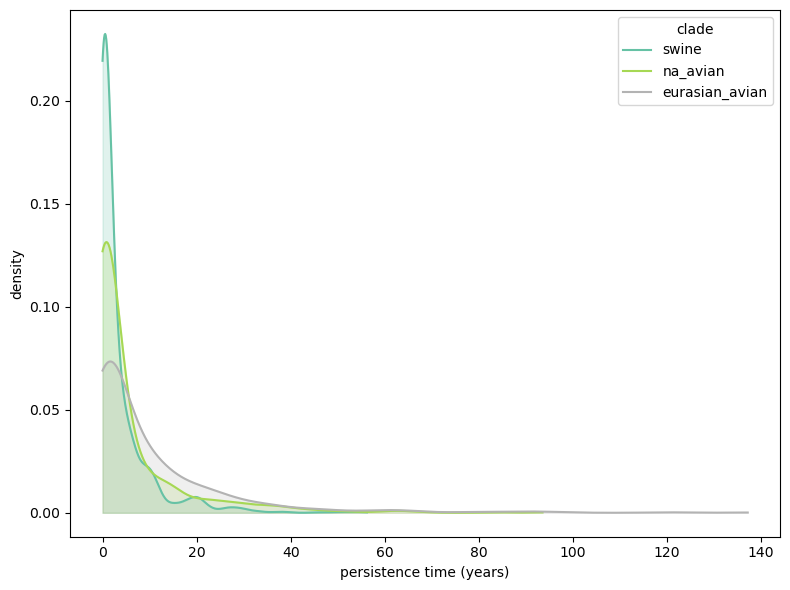

In [22]:
from scipy.stats import gaussian_kde

subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_nonrea_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8,6))

for (clade, persistences), color in zip(filtered.items(), colors):

    x = np.array(persistences)

    kde = gaussian_kde(x)

    xx = np.linspace(min(x), max(x), 500)
    yy = kde(xx)

    # scale so that the area under the curve = 1 → fraction of lineages
    yy = yy / yy.sum() / (xx[1] - xx[0])

    plt.plot(xx, yy, label=clade, color=color)
    plt.fill_between(xx, yy, alpha=0.2, color=color) 

plt.xlabel("persistence time (years)")
plt.ylabel("density")
plt.legend(title="clade")
plt.tight_layout()
plt.show()


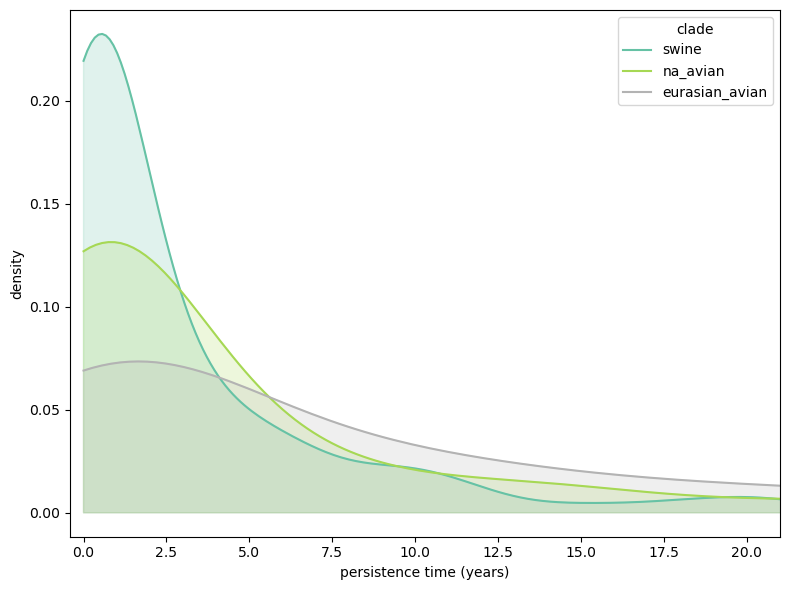

In [23]:
from scipy.stats import gaussian_kde

subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_nonrea_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8,6))

for (clade, persistences), color in zip(filtered.items(), colors):

    x = np.array(persistences)

    kde = gaussian_kde(x)

    xx = np.linspace(min(x), max(x), 500)
    yy = kde(xx)

    # scale so that the area under the curve = 1 → fraction of lineages
    yy = yy / yy.sum() / (xx[1] - xx[0])

    plt.plot(xx, yy, label=clade, color=color)
    plt.fill_between(xx, yy, alpha=0.2, color=color) 

plt.xlabel("persistence time (years)")
plt.ylabel("density")
plt.xlim(-0.4, 21)
plt.legend(title="clade")
plt.tight_layout()
plt.show()


# both

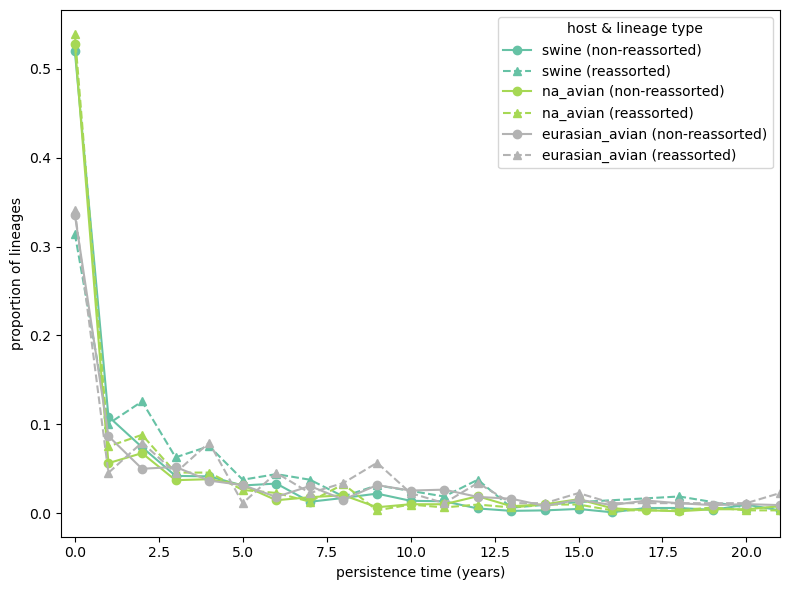

In [24]:
subset = ["swine", "na_avian", "eurasian_avian"]

colors = dict(zip(
    subset,
    plt.cm.Set2(np.linspace(0, 1, len(subset)))
))

plt.figure(figsize=(8,6))

for clade in subset:

    # nonrea (circles)
    persistences = clade_nonrea_persistences[clade]

    binned = np.floor(persistences)
    counts = Counter(binned)
    total = len(persistences)

    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])

    plt.plot(
        years,
        proportions,
        marker="o",
        linestyle="-",
        color=colors[clade],
        label=f"{clade} (non-reassorted)"
    )

    # rea (triangles)
    persistences = clade_persistences[clade]

    binned = np.floor(persistences)
    counts = Counter(binned)
    total = len(persistences)

    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])

    plt.plot(
        years,
        proportions,
        marker="^",
        linestyle="--",
        color=colors[clade],
        label=f"{clade} (reassorted)"
    )

plt.xlabel("persistence time (years)")
plt.ylabel("proportion of lineages")
plt.xlim(-0.4, 21)
plt.legend(title="host & lineage type")
plt.tight_layout()
plt.show()
